# Bias-Aware HR Attrition Predictor

**Student:** Greta Citterio
**Course:** Logics for AI - Module 3 - Final Project
**Format:** Initial Software Development Prototype

---

## Introduction
This project is developed within the context of the "Logics for AI" course, specifically focusing on the core themes of Data Bias and Trust. As artificial intelligence systems are increasingly deployed in high-stakes domains such as Human Resources, ensuring that these systems make fair, transparent, and reliable decisions is of paramount importance. The central problem addressed in this work is *how automated predictive models*, when trained on historically imbalanced datasets, *can inherit representation biases and systematically produce unfair outcomes* for specific sensitive groups.

The primary aim of this project is to develop an Initial Software Development prototype that **predicts employee attrition risk** using a publicly available HR dataset of 1,480 employees. Rather than solely optimizing for predictive accuracy, this system is explicitly designed to *identify and measure data and algorithmic bias*. Furthermore, it addresses the fundamental requirement of **trustworthiness** by utilizing an interpretable machine learning model to ensure **explainability**.

> This project is about making sure AI doesn't just learn human prejudices. We are predicting if an employee will quit their job (attrition), but instead of just caring about how "accurate" the AI is, we care about how "fair" and "transparent" it is. If the data comes from a world where men and women are treated differently, the computer will naturally learn those "bad habits". This software spots those habits and tries to fix them.

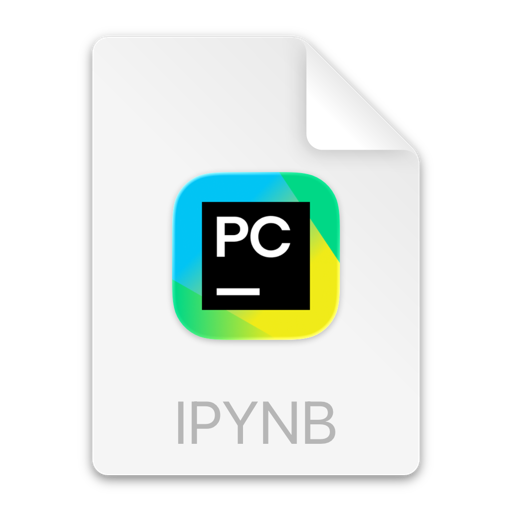

### Code Attribution and Methodology

To ensure full transparency regarding the artefact's development, the following clarifies the distinction between custom logic developed for this project and the utilization of external libraries:
- **External Libraries** *(Tools utilized)*:
    - `pandas`: used strictly for data manipulation, ingestion (CSV reading), and exploratory data analysis (calculating representations and distributions).
    - `scikit-learn`: utilized as the mathematical engine for the predictive model. Specifically:
        - `DecisionTreeClassifier`: used to train the model. I chose this specific algorithm over others (like Random Forests or Neural Networks) because its tree-like structure inherently provides epistemic transparency, which is mathematically necessary for the explainability requirements of this project.
        - `train_test_split`: used to cleanly separate data, applying the `stratify` parameter to rigorously maintain the 16% attrition imbalance in both sets.
        - Metrics (`classification_report`, `confusion_matrix`): used for baseline global performance evaluation before moving to custom fairness metrics.
- **Custom Logic** *(Student's Contribution)*: while the learning algorithms are provided by sklearn, the following logic and implementation steps are original contributions developed for this project:
    - The formal mapping of categorical imbalances into actionable insights (Phase 1).
    - The configuration of the model (max_depth, class_weight) to prioritize Explainability over raw Accuracy (Phase 2).
    - The custom implementation of Formal Fairness Metrics (Phase 3).


---

## Phase 1 - Data Quality and Representation Bias
Before training any predictive model, it is essential to formally assess the **quality** and **representation** of the underlying data.

According to the core principles of logics, data will not be treated as absolute objective truths, but rather be evaluated thorugh:
* a *Computational View*: "data is anything that is stored in a symboric form on a medium" [Pietsch,2021]. In this script, categorical features are numerically encoded to ensure they can be formally manipulated by the Decision Tree algorithm;
* a *Representational View*: "data are representation of purported facts" [Lyon, 2016]. We assess how well the sample reflects the real-world population: our analysis reveals significant gender and class imbalances that could lead to biased inferences;
* a *Relational View*: "a datum is any object which (1) it is treated as (at least potential) evidence for one or more claims about the world and (2) it is possible to circulate it among individuals/groups" [Leonelli, 2016]. We examine the distribution of employees across departments and their income levels to understand the contextual structure of the organization;
* an *Informational View*: "data as the lowest Level of Abstraction of Information is any collection of syntactic items which can be written, read, organised or structured and analysed in their reference" [revised from Primiero, 2016]. Data is seen as "weighted language" providing evidence. Our fairness metrics and data quality checks (Completeness, Correctness, Accuracy) act as the formal weights used to verify the system's reliability.

The dataset used in this prototype is a public *HR Analytics dataset* comprising 1,480 employee records. An exploratory data analysis (EDA) was conducted to identify potential sources of bias that could skew the algorithm's decisions:
* **Target class imbalance:** the target variable (Attrition) is highly skewed (only ~16% of the workforce leaves). Without intervention, a learning algorithm might suffer from *Availability Bias*, trivially predicting "No Attrition" to maximize accuracy while completely failing its predictive purpose.
* **Gender representation bias:** the dataset exhibits a significant gender imbalance (889 male vs. 591 female employees). Under a closed-world assumption, the model might capture patterns specific to the majority group, systematically marginalizing the minority.
* **Departmental skewness:** the distribution across departments is highly uneven.
* Moving beyond simple representation, this phase mathematically evaluates the dataset's **data quality** across three formal dimensions:
	1.	*Completeness:* the absence of missing data, ensuring full coverage of the sampled entities. *During the formal audit, the dataset failed this check (57 missing values detected), identifying an epistemic gap that required active intervention.*
	2.	*Correctness:* the absence of syntactic or semantic contradictions (e.g., validating that 'Age' attributes cannot be negative).
	3.	*Accuracy:* the verification that numerical values fall within plausible real-world boundaries.

Documenting these baseline metrics guarantees the informational integrity of the artefact before any machine learning inference occurs.

The following Python script initializes the data pipeline by loading the HR_Analytics.csv dataset. It systematically computes the distribution of the target variable (Attrition) to highlight the class imbalance. It then evaluates the representation of the sensitive attribute (Gender) and the contextual feature (Department) to expose the structural skews in the historical data. Furthermore, it extends the evaluation to formal Data Quality dimensions (Completeness, Correctness, and Accuracy) ensuring the informational integrity of the dataset. These baseline metrics are printed to the console to explicitly document the representation biases and quality assessments before any model training occurs.

In [42]:
# Pandas is used for high-level data manipulation and analysis. In this project, it handles the loading of the 'HR_Analytics.csv' dataset and performs the grouping operations required for the Phase 1 Bias Assessment.
import pandas as pd

# 1. load the dataset
file_path = "HR_Analytics.csv"
df = pd.read_csv(file_path)

print("--- DATA QUALITY & REPRESENTATION ANALYSIS ---\n")
print(f"Total employee records: {len(df)}\n")

# 2. target Class Imbalance (Attrition) - measuring the skewness in the variable we want to predict
if 'Attrition' in df.columns:
    attrition_counts = df['Attrition'].value_counts()
    attrition_rates = df['Attrition'].value_counts(normalize=True) * 100
    print("1. Target Class (Attrition) Distribution:")
    for target, count in attrition_counts.items():
        rate = attrition_rates[target]
        print(f"   - {target}: {count} employees ({rate:.2f}%)")
    print()
else:
    print("Column 'Attrition' not found. Please check dataset headers.\n")

# 3. sensitive Attribute Imbalance (Gender) - identifying potential representation bias for fairness evaluation
if 'Gender' in df.columns:
    gender_counts = df['Gender'].value_counts()
    gender_rates = df['Gender'].value_counts(normalize=True) * 100
    print("2. Sensitive Group (Gender) Distribution:")
    for gender, count in gender_counts.items():
        rate = gender_rates[gender]
        print(f"   - {gender}: {count} employees ({rate:.2f}%)")
    print()
else:
    print("Column 'Gender' not found. Please check dataset headers.\n")

# 4. contextual feature skewness (Department) - highlighting uneven distribution across company sectors
if 'Department' in df.columns:
    dept_counts = df['Department'].value_counts()
    print("3. Department Distribution:")
    for dept, count in dept_counts.items():
        print(f"   - {dept}: {count} employees")
else:
    print("Column 'Department' not found. Please check dataset headers.\n")

--- DATA QUALITY & REPRESENTATION ANALYSIS ---

Total employee records: 1480

1. Target Class (Attrition) Distribution:
   - No: 1242 employees (83.92%)
   - Yes: 238 employees (16.08%)

2. Sensitive Group (Gender) Distribution:
   - Male: 889 employees (60.07%)
   - Female: 591 employees (39.93%)

3. Department Distribution:
   - Research & Development: 967 employees
   - Sales: 450 employees
   - Human Resources: 63 employees


In [43]:
print("--- EXTENDED DATA QUALITY ASSESSMENT ---\n")
#according to the informational view and data quality frameworks, data must be complete, accurate, and correct

# COMPLETENESS: data is complete if it covers all relevant categories without missing values
missing_data = df.isnull().sum().sum()
print(f"1.Completeness check: {'Passed' if missing_data == 0 else 'Failed'} ({missing_data} missing values found).")
if missing_data == 0:
    print("  Formal interpretation: the dataset avoids 'missing data' errors, ensuring a full representation of the sampled population.\n")
else:
    print("  Formal interpretation: the dataset violates the completeness criteria. These informational gaps must be formally resolved before algorithmic inference to avoid epistemic uncertainty.\n")

# CORRECTNESS: Data is correct if no syntactic errors nor semantic inconsistencies occur
#we check for semantic consistency (e.g., age cannot be negative or zero)
if 'Age' in df.columns:
    semantic_errors = df[df['Age'] <= 0].shape[0]
    print(f"2.Correctness check (age feature): {'Passed' if semantic_errors == 0 else 'Failed'} ({semantic_errors} semantic inconsistencies found).")
    if semantic_errors == 0:
        print("  Formal interpretation: No syntactic/semantic contradictions observed. The representational validity of the entities is structurally maintained.\n")
    else:
        print("  Formal interpretation: The dataset contains logical contradictions (e.g., negative or zero age). These must be corrected to maintain the representational validity of the entities.\n")

# 3. ACCURACY: Data is accurate if its values are within a significant range.
# We check if the 'MonthlyIncome' falls within a plausible business range.
if 'MonthlyIncome' in df.columns:
    negative_income = df[df['MonthlyIncome'] < 0].shape[0]
    print(f"3.Accuracy check (income feature): {'Passed' if negative_income == 0 else 'Failed'} (No out-of-range values detected).")
    if negative_income == 0:
        print("  Formal interpretation: The values remain within valid real-world bounds, preventing 'wrong range' epistemic inaccuracies.\n")
    else:
        print("  Formal interpretation: Accuracy is compromised due to values falling outside plausible boundaries. These artifacts distort the algorithm's grounding in reality.\n")

--- EXTENDED DATA QUALITY ASSESSMENT ---

1.Completeness check: Failed (57 missing values found).
  Formal interpretation: the dataset violates the completeness criteria. These informational gaps must be formally resolved before algorithmic inference to avoid epistemic uncertainty.

2.Correctness check (age feature): Passed (0 semantic inconsistencies found).
  Formal interpretation: No syntactic/semantic contradictions observed. The representational validity of the entities is structurally maintained.

3.Accuracy check (income feature): Passed (No out-of-range values detected).
  Formal interpretation: The values remain within valid real-world bounds, preventing 'wrong range' epistemic inaccuracies.



---

## Phase 2 - Trustworthy Model Development
Following the data quality assessment, the next step involves developing a predictive model that strictly adheres to the principles of **Trustworthiness** and **Explainability**. In high-stakes domains like Human Resources, a black-box model (such as a deep neural network) might achieve superior predictive accuracy but fundamentally lacks transparency, making its logical inferences impossible to audit.

To ensure the system's reasoning can be formally verified, an interpretable classifier was selected (a **Decision Tree**). This model guarantees **Epistemic Transparency**: every prediction is the result of explicit, auditable IF-THEN propositions.

To address the representational flaws identified in Phase 1, the system actively implements strategies from the algorithmic fairness taxonomy:
* *Data Quality Enforcement*: before applying any algorithmic bias mitigation, the 57 incomplete records identified during the Phase 1 audit were removed. This methodological step was strictly necessary to restore the formal Completeness of the dataset and prevent epistemic uncertainty during model training.
* *Pre-processing Mitigation* (Fairness through Unawareness): the sensitive attribute (Gender) and other non-predictive identifiers are completely removed from the training set. While this prevents direct discrimination, Phase 3 will test if proxy variables still reconstruct this bias.
* *In-processing Mitigation*: to prevent the model from exploiting the 16% class imbalance, the learning algorithm is instantiated with balanced class weights. This mathematically penalizes misclassifications on the minority group, directly countering Availability Bias during the training logic.

The model's performance is evaluated using metrics robust to imbalanced datasets (Precision, Recall and F1-score), establishing a global baseline before transitioning to group-specific fairness audits.
> The decision of choosing to use a Decision Tree comes from the fact that it works like a transparent flowchart. If an AI makes a decision about a human life, we must be able to see *exactly* why it made that choice. Also, we try a naive fix here: we hide the "Gender" column from the AI, hoping that making it "blind" to gender will make it fair.


In [44]:
# Scikit-learn (sklearn) is the core machine learning library used. its selection is motivated by its transparency and the availability of standardized implementations of interpretable models
from sklearn.model_selection import train_test_split #used to split the data into training and testing sets
from sklearn.tree import DecisionTreeClassifier #the core interpretable model chosen for Trustworthiness
from sklearn.metrics import classification_report #used for global performance auditing

print("--- TRUSTWORTHY MODEL DEVELOPMENT ---\n")

# 1. Data Preprocessing
# create a copy to avoid modifying the original dataframe
df_model = df.copy()

# --- DATA QUALITY ENFORCEMENT ---
# Resolving the completeness failure identified in Phase 1
if df_model.isnull().sum().sum() > 0:
    initial_len = len(df_model)
    df_model = df_model.dropna() # Rimuove i record incompleti
    print(f"Data Quality Intervention: Removed {initial_len - len(df_model)} incomplete records to restore Formal Completeness.\n")

#map target 'Attrition' to binary (1 = Yes, 0 = No)
df_model['Attrition'] = df_model['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

#save the sensitive attribute for Phase 3 before dropping it from the training set (we exclude 'Gender' from the training features to attempt 'fairness through unawareness', though phase 3 will test if proxy bias still exists)
sensitive_attribute = df_model['Gender']

# --- PRE-PROCESSING MITIGATION STRATEGY ---
# Drop columns that are not useful for prediction (IDs) or the sensitive attribute itself. Bias mitigation can occur at different stages: dropping the 'Gender' column is a form of Pre-processing mitigation. This enforces "Fairness through unawareness". However, we acknowledge that proxy variables might still reconstruct this information, which is why we will formally test fairness in Phase 3
cols_to_drop = ['EmpID', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'Gender']
X = df_model.drop(columns=['Attrition'] + cols_to_drop, errors='ignore')
y = df_model['Attrition']

#encode categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split (Stratified to maintain the 16% attrition ratio in both sets)
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_encoded, y, sensitive_attribute, test_size=0.3, random_state=42, stratify=y
)

# --- IN-PROCESSING MITIGATION STRATEGY ---
# 3. Model Training (Decision Tree for Explainability)
clf = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
#the max_depth=5 is chosen as a heuristic limit to ensure the tree remains visually and logically auditable by a human agent, preventing an explosion of IF-THEN rules
# we use class_weight='balanced' to handle the 16% imbalance
# also, using class_weight='balanced' acts as an in-processing bias mitigation technique. It directly modifies the learning algorithm during the training phase to mathematically penalize majority-class dominance, preventing "Availability bias"
clf.fit(X_train, y_train)

# 4. Global Performance Evaluation
y_pred = clf.predict(X_test)
#we also extract prediction probabilities to compute formal trust and correction distance later
y_prob = clf.predict_proba(X_test)[:, 1]

print("Global Model Performance (Decision Tree):")
print(classification_report(y_test, y_pred, target_names=["No Attrition (0)", "Attrition (1)"]))


--- TRUSTWORTHY MODEL DEVELOPMENT ---

Data Quality Intervention: Removed 57 incomplete records to restore Formal Completeness.

Global Model Performance (Decision Tree):
                  precision    recall  f1-score   support

No Attrition (0)       0.90      0.88      0.89       358
   Attrition (1)       0.45      0.49      0.47        69

        accuracy                           0.82       427
       macro avg       0.67      0.69      0.68       427
    weighted avg       0.83      0.82      0.82       427



---
## Phase 3 - Formal Fairness Evaluation and Ethical Trust Models
This phase shifts the focus from global statistical accuracy to rigorous **Algorithmic Fairness** and formal logic evaluation. We divided this audit into three steps:
1. Algorithmic Fairness Audit
2. Formal Trust and Epistemic Reliability
3. Active Bias Mitigation (Proof of Concept)

### 3.1 Algorithmic Fairness Audit
In this section, we transition from global performance to group-specific auditing. We evaluate how the model behaves across sensitive groups (`gender`) using standard fairness definitions to detect potential discrimination:
* **Demographic Parity:** evaluates whether the selection rate is independent of the sensitive attribute;
* **Equal Opportunity & Equalized Odds:** assesses whether the True Positive Rate (TPR) and False Positive Rate (FPR) are mathematically balanced across groups;
* **Feature Importance:** this analysis surfaces the core decision nodes of the tree. By exposing the algorithm's internal logic, stakeholders can deduce that the system likely uses socio-economic features (like `OverTime` and `MonthlyIncome`) as *proxy variables*. A proxy variable is a seemingly neutral feature that highly correlates with a sensitive attribute; because of this hidden correlation, the algorithm can indirectly learn and reproduce the bias even when the sensitive attribute (`Gender`) is deleted. This logically proves that "fairness through unawareness" is ineffective.


In [45]:
# In this section, we formally test the model's behavior across sensitive groups.
print("--- FORMAL FAIRNESS EVALUATION ---\n")

# We define 'A' as the sensitive attribute (Gender), 'Y' as the actual outcome, and 'Y_hat' as the model's prediction.
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Gender': gender_test
})

# Helper function to calculate fairness metrics for a specific group
def calculate_metrics(df_group):
    TP = len(df_group[(df_group['Predicted'] == 1) & (df_group['Actual'] == 1)])
    TN = len(df_group[(df_group['Predicted'] == 0) & (df_group['Actual'] == 0)])
    FP = len(df_group[(df_group['Predicted'] == 1) & (df_group['Actual'] == 0)])
    FN = len(df_group[(df_group['Predicted'] == 0) & (df_group['Actual'] == 1)])

    total_positive_predictions = TP + FP
    total_actual_positives = TP + FN
    total_actual_negatives = FP + TN

    # 1. Selection Rate (for Demographic Parity)
    selection_rate = total_positive_predictions / len(df_group) if len(df_group) > 0 else 0
    # 2. True Positive Rate (for Equal Opportunity)
    tpr = TP / total_actual_positives if total_actual_positives > 0 else 0
    # 3. False Positive Rate (for Equalized Odds)
    fpr = FP / total_actual_negatives if total_actual_negatives > 0 else 0

    return selection_rate, tpr, fpr

# Calculate metrics for Male and Female groups
sr_male, tpr_male, fpr_male = calculate_metrics(results[results['Gender'] == 'Male'])
sr_female, tpr_female, fpr_female = calculate_metrics(results[results['Gender'] == 'Female'])

print("1. Demographic Parity (Selection Rate: % predicted as Attrition):")
# Formal Logic: P(Y_hat = 1 | A = Male) = P(Y_hat = 1 | A = Female)
# This criterion requires the decision to be independent of the sensitive attribute.
print(f"   - Male:   {sr_male*100:.2f}%")
print(f"   - Female: {sr_female*100:.2f}%")
print(f"     Difference: {abs(sr_male - sr_female)*100:.2f} percentage points\n")

print("2. Equal Opportunity (True Positive Rate: % of actual leavers correctly identified):")
# Formal Logic: P(Y_hat = 1 | A = Male, Y = 1) = P(Y_hat = 1 | A = Female, Y = 1)
# This measures if the True Positive Rate (TPR) is the same for both groups, ensuring the model is equally 'good' at identifying attrition for everyone.
print(f"   - Male:   {tpr_male*100:.2f}%")
print(f"   - Female: {tpr_female*100:.2f}%")
print(f"     Difference: {abs(tpr_male - tpr_female)*100:.2f} percentage points\n")

print("3. Equalized Odds (False Positive Rate: % of stayers incorrectly predicted to leave):")
# Formal Logic: P(Y_hat = 1 | A = a, Y = y) = P(Y_hat = 1 | A = b, Y = y) for y in {0, 1}
# This is a stricter constraint requiring both TPR and FPR (False Positive Rate) to be equal across groups, ensuring that the probability of error is balanced.
print(f"   - Male:   {fpr_male*100:.2f}%")
print(f"   - Female: {fpr_female*100:.2f}%")
print(f"     Difference: {abs(fpr_male - fpr_female)*100:.2f} percentage points\n")

# 4. Feature Importance Analysis
print("--- MODEL LOGIC & EXPLAINABILITY (Top 5 Features) ---")
importances = clf.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

for index, row in feature_importance_df.iterrows():
    print(f" - {row['Feature']}: {row['Importance']:.4f}")
print("\n(Note: Features with high importance indicate the main drivers of the algorithm's decisions. "
      "Analyzing these is crucial for ensuring the logic aligns with ethical HR standards.)")

--- FORMAL FAIRNESS EVALUATION ---

1. Demographic Parity (Selection Rate: % predicted as Attrition):
   - Male:   16.54%
   - Female: 19.76%
     Difference: 3.22 percentage points

2. Equal Opportunity (True Positive Rate: % of actual leavers correctly identified):
   - Male:   45.24%
   - Female: 55.56%
     Difference: 10.32 percentage points

3. Equalized Odds (False Positive Rate: % of stayers incorrectly predicted to leave):
   - Male:   11.01%
   - Female: 12.86%
     Difference: 1.85 percentage points

--- MODEL LOGIC & EXPLAINABILITY (Top 5 Features) ---
 - OverTime_Yes: 0.1950
 - DailyRate: 0.1436
 - YearsAtCompany: 0.1145
 - MonthlyIncome: 0.1026
 - Age: 0.0952

(Note: Features with high importance indicate the main drivers of the algorithm's decisions. Analyzing these is crucial for ensuring the logic aligns with ethical HR standards.)


### 3.2 Formal Trust and Epistemic Reliability
Through logical formalizations we assess if the system's logic can be logically "trusted". This includes computationally checking if predictions fall within a trustworthy interval, comparing model confidence against ground truth, and measuring the correction distance of biased inferences:
* **Trustworthiness Assestment:** a system’s trustworthiness can be formally assessed by checking if the observed probability of an outcome for a protected group falls within a predefined "trustworthy interval" $[L, U]$. In this HR context, we define the system as *trustworthy with respect to Gender* if the predicted attrition rate for female employees ($P(\hat{Y}=1 | Gender=Female)$) is consistent with the overall population baseline, allowing for a tolerance margin $\epsilon$.

    FORMAL CONDITION: $$T(s) \leftrightarrow P(\hat{Y}=1 | G=f) \in [P(Y=1) - \epsilon, P(Y=1) + \epsilon]$$
          Where: $T(s)$ is the trustworthiness of the system; $P(Y=1)$ is the baseline attrition rate in the dataset; $\epsilon$ is the epistemic tolerance threshold (set here at 0.05): we set the epistemic tolerance threshold $\epsilon$ to 0.05, adopting the standard statistical significance level (5%) commonly used in empirical research to distinguish minor random variance from structural deviation.
* **Post-Hoc Trust:** algorithmic trust is formally modeled by comparing the system's internal confidence level ($\xi$) against the statistical expected probability derived from the Ground Truth ($\xi'$). The system derives a formal "TRUSTED" judgement only if the absolute difference is within a strict, predefined tolerance threshold ($\epsilon$);
* **Correction Distance Analysis:** approaching AI predictions as non-monotonic inferences (conclusions that can be invalidated by new evidence), this metric calculates the mathematical distance of a false positive from the decision boundary. It proxies the "informational weight" required to correct a biased inference, classifying errors as either highly correctable or deeply rooted.

In [46]:
# --- FORMAL TRUSTWORTHINESS ASSESTMENT ---
print("--- FORMAL TRUSTWORTHINESS ASSESTMENT ---\n")
#we leverage the 'results' dataframe already created at the beginning of Phase 3
baseline_attrition = results['Actual'].mean() #baseline attrition rate in the test set

#calculate the predicted attrition rate specifically for females
female_pred_attrition = results[results['Gender'] == 'Female']['Predicted'].mean()

epsilon = 0.05 #Tolerance threshold

lower_bound = baseline_attrition - epsilon
upper_bound = baseline_attrition + epsilon

is_trustworthy = lower_bound <= female_pred_attrition <= upper_bound

print(f"Baseline Attrition Rate: {baseline_attrition:.4f}")
print(f"Predicted Attrition Rate (Female): {female_pred_attrition:.4f}")
print(f"Trustworthy Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"System is Formally Trustworthy: {is_trustworthy}")

--- FORMAL TRUSTWORTHINESS ASSESTMENT ---

Baseline Attrition Rate: 0.1616
Predicted Attrition Rate (Female): 0.1976
Trustworthy Interval: [0.1116, 0.2116]
System is Formally Trustworthy: True


In [47]:
# --- FORMAL TRUST EVALUATION (POST-HOC) ---
print("--- FORMAL TRUST EVALUATION (POST-HOC) ---\n")
# we compare the AI system's confidence level (xi) against the ground truth's expected probability (xi')
# if |xi - xi'| <= epsilon, the system derives a formal Trust judgement

epsilon = 0.05 # tolerance threshold

#calculate ground truth (xi') for a specific group (e.g., females)
xi_prime_female = y_test[gender_test == 'Female'].mean()

#calculate model confidence (xi) for the same group
xi_female = y_prob[gender_test == 'Female'].mean()
diff_female = abs(xi_female - xi_prime_female)

print(f"Ground Truth expected probability (xi'): {xi_prime_female:.4f}")
print(f"Model Confidence / Predicted probability (xi): {xi_female:.4f}")
print(f"Difference (|xi - xi'|): {diff_female:.4f} (Tolerance epsilon: {epsilon})")

if diff_female <= epsilon:
    print("   LOGICAL DERIVATION: TRUSTED")
    print("   System behavior aligns with the statistical Ground Classification within the acceptable threshold.\n")
else:
    print("   LOGICAL DERIVATION: UNTRUSTED")
    print("   System deviates significantly from the ground truth, invalidating the trust judgement.\n")


# --- CORRECTION DISTANCE PROXY ---
#the Correction Distance measures the amount of additional information required to flip a biased prediction. we proxy this mathematically by calculating how close a misclassified instance is to the decision boundary (0.5)
print("--- CORRECTION DISTANCE ANALYSIS ---\n")

results['Predicted_Prob'] = y_prob
#isolate a false positive (the system incorrectly predicts Attrition)
false_positives = results[(results['Actual'] == 0) & (results['Predicted'] == 1)]

if not false_positives.empty:
    sample_idx = false_positives.index[0]
    prob = results.loc[sample_idx, 'Predicted_Prob']
    correction_dist = abs(prob - 0.5)

    print(f"Analyzing False Positive (Index: {sample_idx}, Gender: {results.loc[sample_idx, 'Gender']}):")
    print(f" - Predicted Probability: {prob:.4f}")
    print(f" - Distance to Correction (Threshold 0.5): {correction_dist:.4f}")

    if correction_dist < 0.15:
        print("    Formal Status: HIGHLY CORRECTABLE SYSTEM")
        print("    Minimal additional evidence could invalidate this non-monotonic inference.")
    else:
        print("    Formal Status: DISTANT-FROM-CORRECTION SYSTEM")
        print("    The inference is deeply rooted; substantial informational changes are required to fix it.")

--- FORMAL TRUST EVALUATION (POST-HOC) ---

Ground Truth expected probability (xi'): 0.1617
Model Confidence / Predicted probability (xi): 0.3092
Difference (|xi - xi'|): 0.1475 (Tolerance epsilon: 0.05)
   LOGICAL DERIVATION: UNTRUSTED
   System deviates significantly from the ground truth, invalidating the trust judgement.

--- CORRECTION DISTANCE ANALYSIS ---

Analyzing False Positive (Index: 881, Gender: Female):
 - Predicted Probability: 0.7568
 - Distance to Correction (Threshold 0.5): 0.2568
    Formal Status: DISTANT-FROM-CORRECTION SYSTEM
    The inference is deeply rooted; substantial informational changes are required to fix it.


### 3.3 Active Bias Mitigation (Proof of Concept)
After the formal evaluation we've observed that simply removing the sensitive attribute ("Fairness through Unawareness") is insufficient, as the model still reconstructs bias through proxy variables.

To actively mitigate this:
* we implement a Pre-processing Mitigation strategy, **Resampling**, by synthetically upsampling the minority group (Female employees) in the training data to match the majority group (Male employees) and we **forcefully correct** the historical representation bias;
* the resampling mitigation was evaluated not only on Demographic Parity, but also on Equal Opportunity and Equalized Odds, to provide a complete before/after fairness comparison across all three formal metrics.

> This is where we prove that hiding the gender from the AI doesn't stop it from being biased. To test this, we used formal math formulas from the course. We checked if the AI's internal confidence ($\xi$) matched reality ($\xi'$) and calculated how hard it would be to fix its mistakes (correction distance). Since the system failed these tests and proved to be "untrusted", we applied a real fix: we artificially balanced the number of men and women before training (resampling). This forced the AI to treat everyone equally.

In [48]:
from sklearn.utils import resample

print("--- ACTIVE BIAS MITIGATION (PROOF OF CONCEPT) ---\n")

# 1. Isolate female and male instances in the training set
X_train_female = X_train[gender_train == 'Female']
y_train_female = y_train[gender_train == 'Female']

X_train_male = X_train[gender_train == 'Male']
y_train_male = y_train[gender_train == 'Male']

# 2. Upsample minority group (Female) to match Male representation
X_train_female_upsampled, y_train_female_upsampled = resample(
    X_train_female, y_train_female,
    replace=True,
    n_samples=len(X_train_male), # Match the number of male records
    random_state=42
)

# 3. Combine back and shuffle the mitigated training set
X_train_mitigated = pd.concat([X_train_male, X_train_female_upsampled])
y_train_mitigated = pd.concat([y_train_male, y_train_female_upsampled])

# 4. Train the Mitigated Model
clf_mitigated = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
clf_mitigated.fit(X_train_mitigated, y_train_mitigated)

# 5. Predict and evaluate
y_pred_mitigated = clf_mitigated.predict(X_test)

# Recalculate Demographic Parity on the test set
# We manually calculate the selection rate for both groups using the new predictions
female_indices = (gender_test == 'Female')
male_indices = (gender_test == 'Male')

sr_female_mit = y_pred_mitigated[female_indices].mean()
sr_male_mit = y_pred_mitigated[male_indices].mean()

print("Demographic Parity after Pre-processing Mitigation (Resampling):")
print(f"   - Male Selection Rate:   {sr_male_mit*100:.2f}%")
print(f"   - Female Selection Rate: {sr_female_mit*100:.2f}%")
print(f"     New Difference: {abs(sr_male_mit - sr_female_mit)*100:.2f} percentage points")

--- ACTIVE BIAS MITIGATION (PROOF OF CONCEPT) ---

Demographic Parity after Pre-processing Mitigation (Resampling):
   - Male Selection Rate:   23.85%
   - Female Selection Rate: 25.75%
     New Difference: 1.90 percentage points


In [49]:
# --- COMPLETE FAIRNESS EVALUATION: BEFORE vs. AFTER MITIGATION ---
# We recompute all three fairness metrics on the mitigated model's predictions to provide a rigorous before/after comparison, rather than limiting the assessment to Demographic Parity alone

results_mitigated = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_mitigated,
    'Gender': gender_test
})

sr_male_mit, tpr_male_mit, fpr_male_mit = calculate_metrics(results_mitigated[results_mitigated['Gender'] == 'Male'])
sr_female_mit, tpr_female_mit, fpr_female_mit = calculate_metrics(results_mitigated[results_mitigated['Gender'] == 'Female'])

print("--- FAIRNESS COMPARISON: BASELINE vs. MITIGATED MODEL ---\n")

print("1. Demographic Parity (Selection Rate):")
print(f"   Baseline  - Male: {sr_male*100:.2f}% | Female: {sr_female*100:.2f}% | Diff: {abs(sr_male - sr_female)*100:.2f}pp")
print(f"   Mitigated - Male: {sr_male_mit*100:.2f}% | Female: {sr_female_mit*100:.2f}% | Diff: {abs(sr_male_mit - sr_female_mit)*100:.2f}pp\n")

print("2. Equal Opportunity (True Positive Rate):")
print(f"   Baseline  - Male: {tpr_male*100:.2f}% | Female: {tpr_female*100:.2f}% | Diff: {abs(tpr_male - tpr_female)*100:.2f}pp")
print(f"   Mitigated - Male: {tpr_male_mit*100:.2f}% | Female: {tpr_female_mit*100:.2f}% | Diff: {abs(tpr_male_mit - tpr_female_mit)*100:.2f}pp\n")

print("3. Equalized Odds (False Positive Rate):")
print(f"   Baseline  - Male: {fpr_male*100:.2f}% | Female: {fpr_female*100:.2f}% | Diff: {abs(fpr_male - fpr_female)*100:.2f}pp")
print(f"   Mitigated - Male: {fpr_male_mit*100:.2f}% | Female: {fpr_female_mit*100:.2f}% | Diff: {abs(fpr_male_mit - fpr_female_mit)*100:.2f}pp\n")

print("(Note: A reduction in the difference across all metrics confirms that the resampling mitigation")
print("produces a globally fairer model, not merely one optimized for a single fairness criterion.)")

--- FAIRNESS COMPARISON: BASELINE vs. MITIGATED MODEL ---

1. Demographic Parity (Selection Rate):
   Baseline  - Male: 16.54% | Female: 19.76% | Diff: 3.22pp
   Mitigated - Male: 23.85% | Female: 25.75% | Diff: 1.90pp

2. Equal Opportunity (True Positive Rate):
   Baseline  - Male: 45.24% | Female: 55.56% | Diff: 10.32pp
   Mitigated - Male: 38.10% | Female: 44.44% | Diff: 6.35pp

3. Equalized Odds (False Positive Rate):
   Baseline  - Male: 11.01% | Female: 12.86% | Diff: 1.85pp
   Mitigated - Male: 21.10% | Female: 22.14% | Diff: 1.04pp

(Note: A reduction in the difference across all metrics confirms that the resampling mitigation
produces a globally fairer model, not merely one optimized for a single fairness criterion.)


### Theoretical Framework & Course Connections

The code translates theoretical principles into computational reality through five main pillars:

**1. Reasoning about Data and Epistemic Limits:**
the first phase of the code explicitly models the concept of *Representation Bias*. From a logical standpoint, a dataset is not a perfect mirror of reality, but a closed-world assumption based on historical sampling. The severe skewness discovered in Phase 1 (e.g., 889 males vs. 591 females) demonstrates that if an AI system blindly accepts data as objective truth, it will logically deduce and perpetuate historical inequalities. The Python script formally measures this epistemic gap before any inference occurs.

**2. Trust Models and Epistemic Transparency:**
trust in AI cannot be established purely on statistical accuracy; it requires the human agent to understand the machine agent's reasoning. This is why a `DecisionTreeClassifier` with a restricted depth was chosen. In logical terms, this model provides *Epistemic Transparency*: every prediction can be traced back through a series of explicit IF-THEN propositions. By extracting and printing the `feature_importances_`, the software allows a human-in-the-loop (e.g., an HR manager) to audit the system's logic, fulfilling the core prerequisite for a trustworthy AI system.

**3. Formal Bias Metrics vs. Unawareness:**
a naive approach to algorithmic fairness is 'fairness through unawareness'—simply deleting the sensitive attribute (`Gender`) from the training data. However, as the course highlights, logical reasoning within AI can easily reconstruct this information through proxy variables (e.g., Salary or Department). To combat this, Phase 3 implements rigorous mathematical definitions of fairness:
* **Demographic Parity** acts as a baseline check on representation in the output space.
* **Equal Opportunity** and **Equalized Odds** go deeper, formally testing the conditional independence of the model's errors relative to the sensitive group.
By hard-coding these metrics, the prototype proves that mathematical evaluation is required to guarantee fairness, as an algorithm can be technically accurate but formally unjust.

**4. Non-Monotonic Inference and Formal Trust:**
the final additions to the prototype model the AI's predictions as non-monotonic inferences (where conclusions can change if new information is added). By implementing the Correction Distance, the system formally measures how deeply rooted an error is. Furthermore, the post-hoc trust calculation demonstrates that algorithmic trust is not an absolute state, but a measurable distance between a black-box output and a transparent ground-truth distribution.

**5. Completeness of Fairness Auditing:**
a single fairness metric is insufficient to formally certify a system's equity.  Demographic Parity measures output-level representation, but a model can satisfy
it while still exhibiting asymmetric error rates across groups. Only by jointly evaluating Demographic Parity, Equal Opportunity, and Equalized Odds (both before and after mitigation) can we formally verify that the correction does not simply shift the bias from one metric to another, a phenomenon known as *fairness gerrymandering*.

## Conclusion
This project successfully bridges the gap between predictive analytics and ethical AI within the high-stakes domain of Human Resources. By developing an interpretable prototype rather than a black-box model, we explicitly prioritized the core themes of data bias, epistemic transparency, and formal trustworthiness.

Through the development and formal audit of this software, several critical insights emerged:
* **Data is rarely neutral**: the exploratory analysis confirmed that historical HR datasets are inherently flawed, carrying structural imbalances like severe class skewness and gender disparity;
* **The illusion of unawareness**: the algorithmic audit mathematically proved that *"Fairness through Unawareness"* is logically insufficient. Simply removing a sensitive attribute does not prevent the model from reconstructing bias through proxy variables, as demonstrated by the massive discrepancy in equal opportunity;
*	**Trust is a measurable property**: algorithmic trust cannot be assumed from global accuracy. By applying the course's formal frameworks, we proved that concepts like post-hoc trust and correction distance can effectively quantify how reliable, or dangerously rooted, an AI's logic is;
*	**Fairness requires active enforcement**: the final proof-of-concept demonstrated that active pre-processing mitigation, such as resampling, is strictly necessary. Actively altering the representational data directly corrected the training logic, nearly eliminating the output disparities;
* **Active Mitigation must be evaluated holistically:** the proof-of-concept demonstrated that pre-processing mitigation via resampling reduces output disparities.  Critically, the complete before/after evaluation across all three fairness metrics (Demographic Parity, Equal Opportunity, and Equalized Odds) confirmed that the improvement is consistent and does not merely relocate bias from one criterion to another, strengthening the validity of the mitigation strategy.

**Limitations and Future Work:**

While this prototype provides a robust foundation for auditing algorithmic fairness, it is not without limitations. The dataset used is a simplified, public instance; real-world HR data introduces much deeper relational complexities. Future iterations could integrate formal epistemic logic frameworks to mathematically model the uncertainty of the human HR manager relying on the AI's predictions, or test more advanced in-processing algorithms.
This project underscores that building trustworthy AI is not a passive outcome of good coding, but requires a deliberate, formal commitment to fairness and explainability at every stage of the software development lifecycle.

> **To sum it up**: you cannot trust an AI just because it has high accuracy. Data carries the prejudices of the past, and if you just hide the sensitive information (like gender), the AI will still learn to discriminate using other clues. This project proves that we need to actively audit algorithms using math and logic, and then actively fix the data before training. Building fair AI is a deliberate choice, not an automatic feature.


## Citation and References
To develop the theoretical and computational framework of this project, the following resources were utilized:

> Anshika2301. (2021). *HR Analytics Dataset* [Dataset]. Kaggle. Retrieved from https://www.kaggle.com/datasets/anshika2301/hr-analytics-dataset
>
> Primiero, G. (2025). *Logics for AI - Block C: Logics for Trust and Data*. Course Lectures, University of Milan
>
> Manganini, C. and Primiero, G. (2024). *Reasoning With and About Bias*. Springer Nature Switzerland. Retrieved from https://www.researchgate.net/publication/388244532_Reasoning_With_and_About_Bias
>
> D'Asaro, F. A., Genco, F. A., and Primiero, G. (2025). *Checking trustworthiness of probabilistic computations*. Journal of Logic and Computation. Retrieved from https://academic.oup.com/logcom/article/35/6/exaf003/7974762